### STEP 1: IMPORT CRUCIAL LIBRARIES ###

In [1]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install transformers

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install transformers torch scikit-learn accelerate 

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import torch
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW # Import AdamW từ torch.optim thay vì transformers
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Kiểm tra thiết bị (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working on device: {device}")

Working on device: cpu


### Step 2: EDA ###

In [9]:
try:
    df1 = pd.read_csv('../Datasets/Dataset01.csv', encoding='latin-1')
    print("Dataset 01 loaded. Columns:", df1.columns.tolist())
except Exception as e: print(f"Error Dataset 01: {e}")

try:
    df2 = pd.read_csv('../Datasets/Dataset02.csv')
    print("Dataset 02 loaded. Columns:", df2.columns.tolist())
except Exception as e: print(f"Error Dataset 02: {e}")

try:
    df3 = pd.read_csv('../Datasets/Dataset03.csv')
    print("Dataset 03 loaded. Columns:", df3.columns.tolist())
except Exception as e: print(f"Error Dataset 03: {e}")

try:
    df4 = pd.read_csv('../Datasets/Dataset04.csv')
    print("Dataset 04 loaded. Columns:", df4.columns.tolist())
except Exception as e: print(f"Error Dataset 04: {e}")

Dataset 01 loaded. Columns: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
Dataset 02 loaded. Columns: ['Unnamed: 0', 'label', 'text', 'label_num']
Dataset 03 loaded. Columns: ['text', 'spam']
Dataset 04 loaded. Columns: ['Message ID', 'Subject', 'Message', 'Spam/Ham', 'Date']


--- Detailed Noise Report per File ---


,Total Rows,Missing Text,Duplicates,HTML/Encoding Artifacts,Special Char Errors,Contains URLs
Dataset 01 (SMS),5572,0,403,250,481,107
Dataset 02 (Email),5171,0,178,0,0,9
Dataset 03 (Email),5728,0,33,0,0,15
Dataset 04 (Enron),33716,371,3936,0,982,96


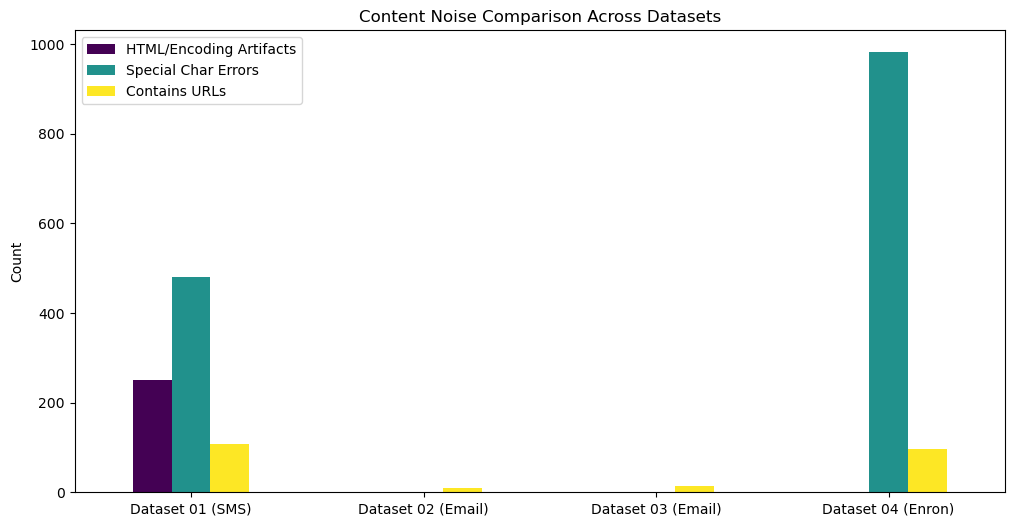

In [12]:
import re 

def get_noise_metrics(df, text_column):
    total = len(df)
    # 1. Missing & Duplicates
    missing = df[text_column].isnull().sum()
    dupes = df.duplicated(subset=[text_column]).sum()
    
    # 2. Content Noise (áp dụng cho các dòng không NaN)
    texts = df[text_column].astype(str)
    html_artifacts = texts.apply(lambda x: bool(re.search(r'&lt;|&gt;|<.*?>', x))).sum()
    encoding_errors = texts.apply(lambda x: bool(re.search(r'[^\x00-\x7F]+', x))).sum() # Ký tự lạ ngoài ASCII
    url_count = texts.apply(lambda x: bool(re.search(r'http\S+|www\S+', x))).sum()
    
    return {
        "Total Rows": total,
        "Missing Text": missing,
        "Duplicates": dupes,
        "HTML/Encoding Artifacts": html_artifacts,
        "Special Char Errors": encoding_errors,
        "Contains URLs": url_count
    }

analysis = {
    "Dataset 01 (SMS)": get_noise_metrics(df1, 'v2'),
    "Dataset 02 (Email)": get_noise_metrics(df2, 'text'),
    "Dataset 03 (Email)": get_noise_metrics(df3, 'text'),
    "Dataset 04 (Enron)": get_noise_metrics(df4, 'Message')
}

# Hiển thị dưới dạng DataFrame cho dễ nhìn
noise_report = pd.DataFrame(analysis).T
print("--- Detailed Noise Report per File ---")
display(noise_report)

# Vẽ biểu đồ so sánh Noise giữa các file
noise_report[['HTML/Encoding Artifacts', 'Special Char Errors', 'Contains URLs']].plot(
    kind='bar', figsize=(12, 6), colormap='viridis'
)
plt.title('Content Noise Comparison Across Datasets')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

Directory '../Figures' already exists.
Figure saved at: ../Figures\noise_comparison_report.png


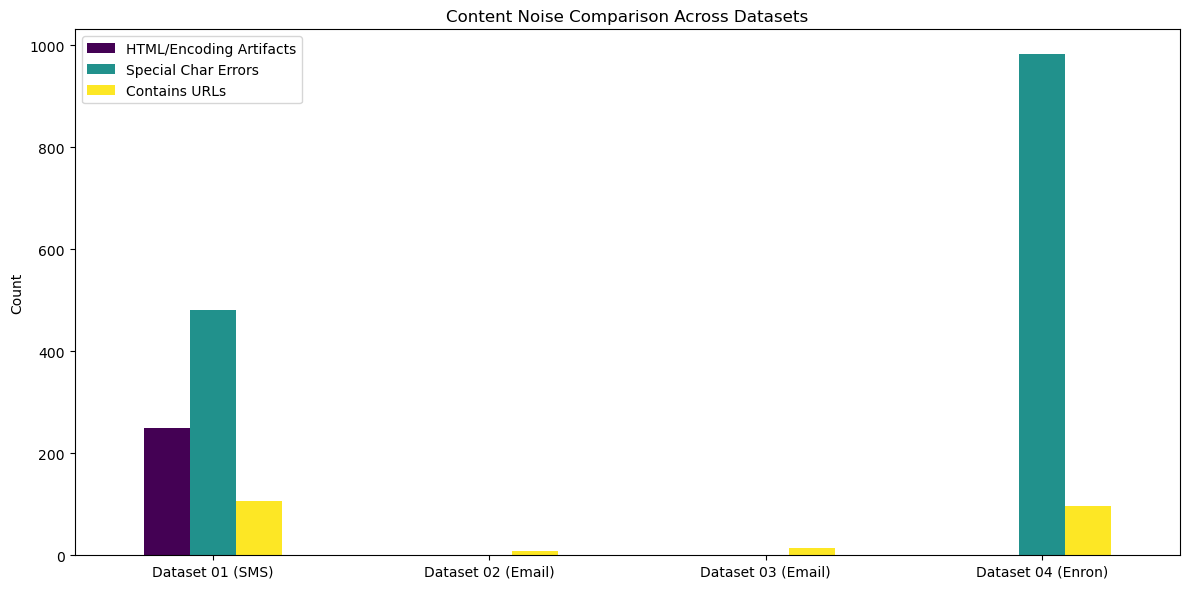

In [13]:
# 1. Tạo folder 'Figures' nếu chưa có
folder_path = '../Figures'
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Directory '{folder_path}' created successfully!")
else:
    print(f"Directory '{folder_path}' already exists.")

# 2. Vẽ lại biểu đồ và Lưu (Save)
# Tui lấy lại code vẽ biểu đồ so sánh Noise lúc nãy nhé
noise_report[['HTML/Encoding Artifacts', 'Special Char Errors', 'Contains URLs']].plot(
    kind='bar', figsize=(12, 6), colormap='viridis'
)

plt.title('Content Noise Comparison Across Datasets')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()

# --- LỆNH LƯU HÌNH ---
# bbox_inches='tight' giúp hình không bị mất lề khi lưu
save_path = os.path.join(folder_path, 'noise_comparison_report.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')

print(f"Figure saved at: {save_path}")
plt.show()

### Step 3: Clean data ###

In [14]:
import re

# 1. Chuẩn hóa và Gộp (Consolidation)
df1_clean = df1[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})
df2_clean = df2[['label', 'text']]
df3_clean = df3[['text', 'spam']].rename(columns={'spam': 'label'})
df3_clean['label'] = df3_clean['label'].map({0: 'ham', 1: 'spam'})
df4_clean = df4[['Spam/Ham', 'Message']].rename(columns={'Spam/Ham': 'label', 'Message': 'text'})

df_merged = pd.concat([df1_clean, df2_clean, df3_clean, df4_clean], ignore_index=True)

# 2. Hàm dọn dẹp chuyên sâu cho BERT
def deep_clean(text):
    text = str(text).lower()
    # Loại bỏ HTML Entities (ví dụ: &lt; # &gt;)
    text = re.sub(r'&[a-z0-9#]+;', '', text)
    # Loại bỏ URL
    text = re.sub(r'http\S+|www\S+', '', text)
    # Loại bỏ ký tự lỗi Encoding (Non-ASCII như 憯)
    text = re.sub(r'[^\x00-\x7f]', r'', text)
    # Loại bỏ các dòng Forwarded/Subject thừa thãi
    text = re.sub(r'subject:|forwarded by.*|to:|cc:|from:', '', text)
    # Loại bỏ khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Thực thi dọn dẹp
df_merged['text'] = df_merged['text'].apply(deep_clean)

# 3. Xử lý Missing Values và Duplicates sau khi dọn dẹp
# (Vì sau khi dọn dẹp, nhiều email có thể trở nên giống hệt nhau hoặc bị trống)
df_merged.replace('', np.nan, inplace=True)
df_merged.dropna(subset=['text', 'label'], inplace=True)
df_merged.drop_duplicates(subset=['text'], inplace=True)

# 4. Chuyển nhãn về dạng số (Mapping)
label_map = {'ham': 0, 'spam': 1}
df_merged['label'] = df_merged['label'].str.lower().map(label_map)

# Kiểm tra kết quả cuối cùng
print("--- Final Dataset Statistics ---")
print(f"Total clean samples: {len(df_merged)}")
print(df_merged['label'].value_counts())

# Lưu file sạch để dùng cho training
df_merged.to_csv('final_cleaned_dataset.csv', index=False)

--- Final Dataset Statistics ---
Total clean samples: 45001
label
0    27678
1    17323
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_9160\3617528295.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_merged, palette='viridis')


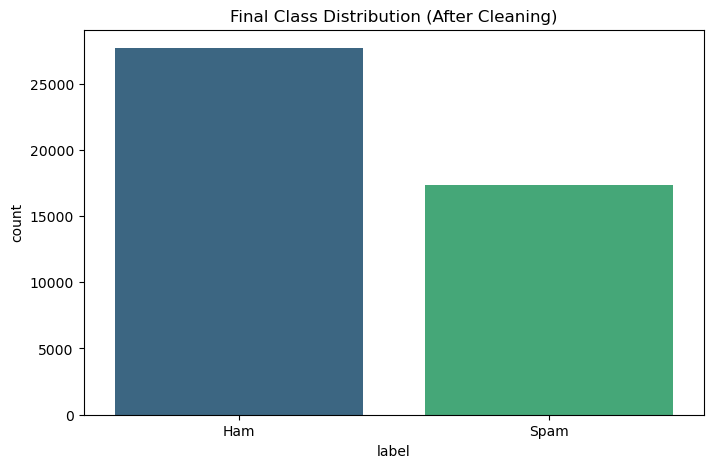

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df_merged, palette='viridis')
plt.title('Final Class Distribution (After Cleaning)')
plt.xticks([0, 1], ['Ham', 'Spam'])
plt.savefig('../Figures/final_distribution.png')
plt.show()

In [17]:
import os
import numpy as np

# 1. Cấu hình số lượng file muốn chia (ví dụ chia làm 5 file)
num_files = 5
output_folder = '../Processed'

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# 2. Chia dataframe dùng numpy split
# np.array_split đảm bảo chia đều ngay cả khi số lượng dòng không chia hết cho num_files
df_split = np.array_split(df_merged, num_files)

print(f"--- Splitting Process Starting ---")
for i, chunk in enumerate(df_split):
    # Tạo tên file theo format ông muốn: SpamHamCleaned01.csv, 02.csv...
    file_name = f"SpamHamCleaned{i+1:02d}.csv"
    file_path = os.path.join(output_folder, file_name)
    
    # Lưu chunk ra csv
    chunk.to_csv(file_path, index=False)
    print(f"Saved: {file_path} | Rows: {len(chunk)}")

print(f"\nSuccess! All {num_files} files are ready in the '{output_folder}' folder.")

c:\Users\DELL\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


--- Splitting Process Starting ---
Saved: ../Processed\SpamHamCleaned01.csv | Rows: 9001
Saved: ../Processed\SpamHamCleaned02.csv | Rows: 9000
Saved: ../Processed\SpamHamCleaned03.csv | Rows: 9000
Saved: ../Processed\SpamHamCleaned04.csv | Rows: 9000
Saved: ../Processed\SpamHamCleaned05.csv | Rows: 9000

Success! All 5 files are ready in the '../Processed' folder.


### Step 4: Model Learning and Training ###

In [18]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, AdamW
import pandas as pd
import glob

ImportError: cannot import name 'AdamW' from 'transformers' (c:\Users\DELL\anaconda3\Lib\site-packages\transformers\__init__.py)